In [1]:
import adaptive_latents as al
from adaptive_latents import NumpyTimedDataSource, Bubblewrap, AnimationManager, default_rwd_parameters, BWRun
from adaptive_latents.transforms.utils import prosvd_data, clip
import numpy as np
import matplotlib
#matplotlib.use('TkAgg')
import matplotlib.pylab as plt
from matplotlib.patches import Ellipse
from math import atan2, floor
from matplotlib.animation import FuncAnimation

In [2]:
# Specify the paths to the files
stim_file_path = '../workspace/datasets/fish/output_020424_ds1/stimmed.txt'
C_file_path = '../workspace/datasets/fish/output_020424_ds1/analysis_proc_C.txt'
photo_file_path = '../workspace/datasets/fish/output_020424_ds1/photostims.npy'

# Load the files
stim = np.loadtxt(stim_file_path) 
"""1st entry: frame number,
2nd entry: ignore,
3rd entry: angle of motion L,
4th entry: angle of motion R,
5th entry: timestamp,"""
C = np.loadtxt(C_file_path)#
"""Calcium imaging. 
1st entry is neuron ID,
2nd is time (frame)"""
photostim = np.load(photo_file_path)
"""1st entry: frame number,
2nd entry: counter of stims,
3rd entry: neuron ID,
4th entry: position X of neuron,
5th entry: position Y of neuron,"""

# extra note: Fs= 2.3 Hz

'1st entry: frame number,\n2nd entry: counter of stims,\n3rd entry: neuron ID,\n4th entry: position X of neuron,\n5th entry: position Y of neuron,'

In [3]:
mediumC_photo = C[:200,]


In [4]:
smallC_photo = prosvd_data(mediumC_photo.T,2, 20, centering=True)

  0%|          | 0/5385 [00:00<?, ?it/s]

100%|██████████| 5385/5385 [00:00<00:00, 9911.49it/s] 


In [5]:
t = np.arange(smallC_photo.shape[0])
in_ds = NumpyTimedDataSource(smallC_photo, t, time_offsets=(0,1))
bw = Bubblewrap(dim=in_ds.output_shape, **dict(default_rwd_parameters, M=100, num=1000, B_thresh=-10, num_grad_q=1))

In [6]:
br = BWRun(bw=bw, in_ds=in_ds)
br.run(limit=3000, save=False)

  3%|▎         | 99/3000 [00:02<01:20, 36.02it/s]


XlaRuntimeError: INTERNAL: CustomCall failed: jaxlib/gpu/solver_kernels.cc:45: operation gpusolverDnCreate(&handle) failed: cuSolver internal error

: 

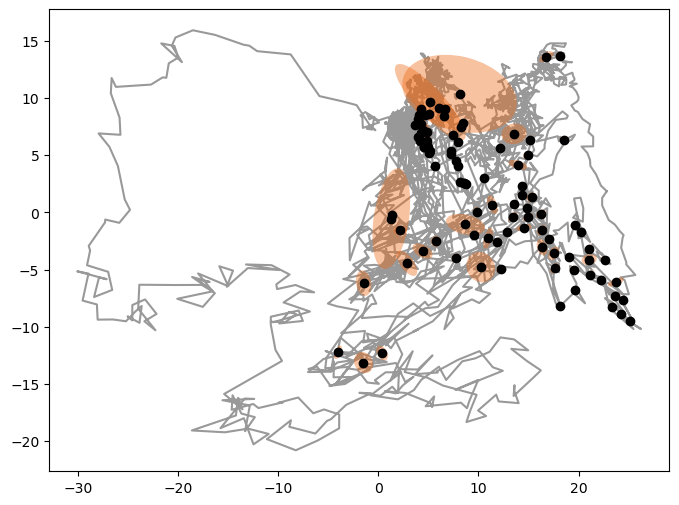

In [16]:
#Plotting

data = smallC_photo
A = bw.A
mu = bw.mu
L = bw.L
n_obs = bw.n_obs

# Create the figure and axis
fig, axs = plt.subplots(figsize=(8, 6))

# Plot the trajectory data
axs.plot(data[:, 0], data[:, 1], color='gray', alpha=0.8)

# Determine appropriate limits and ticks for x and y axes
x_min, x_max = np.min(mu[:, 0]), np.max(mu[:, 0])
y_min, y_max = np.min(mu[:, 1]), np.max(mu[:, 1])
x_range = x_max - x_min
y_range = y_max - y_min
x_ticks = np.linspace(x_min, x_max, num=5)
y_ticks = np.linspace(y_min, y_max, num=5)

# Set axis properties
"""
axs.set_xlim(x_min - 0.1 * x_range, x_max + 0.1 * x_range)
axs.set_ylim(y_min - 0.1 * y_range, y_max + 0.1 * y_range)
axs.set_xticks(x_ticks)
axs.set_yticks(y_ticks)
in1, in2 = -0.15, 1
axs.text(in1, in2, s='a', transform=axs.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')
"""
# Plot ellipses and scatter points using the same mask
mask = n_obs >= 0.5
for n in np.where(mask)[0]:
    if n_obs[n] > 0.2:
        el = np.linalg.inv(L[n])
        sig = el.T @ el
        u, s, v = np.linalg.svd(sig)
        width, height = np.sqrt(s[0]) * 3, np.sqrt(s[1]) * 3
        angle = atan2(v[0, 1], v[0, 0]) * 360 / (2 * np.pi)
        ellipse = Ellipse((mu[n, 0], mu[n, 1]), width, height, angle=angle, zorder=8)
        ellipse.set_alpha(0.4)
        ellipse.set_clip_box(axs.bbox)
        ellipse.set_facecolor('#ed6713')
        axs.add_artist(ellipse)

axs.scatter(mu[mask, 0], mu[mask, 1], c='k', zorder=10)

plt.show()


### Let's make a video

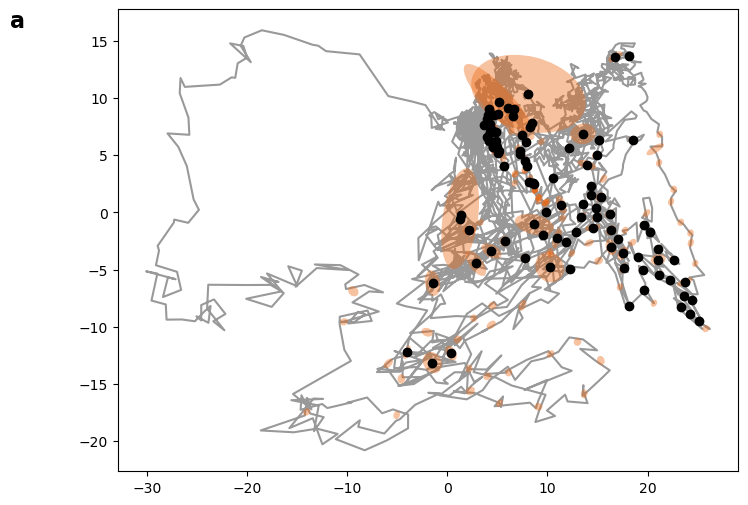

In [9]:

data = smallC_photo
A = bw.A
mu = bw.mu
L = bw.L
n_obs = bw.n_obs

# Create the figure and axis
fig, axs = plt.subplots(figsize=(8, 6))

# Initial plot setup
axs.plot(data[:, 0], data[:, 1], color='gray', alpha=0.8)
scatter = axs.scatter([], [], c='k', zorder=10)
ellipses = []

# Initialize plot elements
def init():
    scatter.set_offsets(np.empty((0, 2)))
    for ellipse in ellipses:
        ellipse.remove()
    ellipses.clear()
    return scatter,

# Update function for animation
def update(frame):
    n = frame
    if n_obs[n] > 0.2:
        el = np.linalg.inv(L[n])
        sig = el.T @ el
        u, s, v = np.linalg.svd(sig)
        width, height = np.sqrt(s[0]) * 3, np.sqrt(s[1]) * 3
        angle = atan2(v[0, 1], v[0, 0]) * 360 / (2 * np.pi)
        ellipse = Ellipse((mu[n, 0], mu[n, 1]), width, height, angle=angle, zorder=8)
        ellipse.set_alpha(0.4)
        ellipse.set_clip_box(axs.bbox)
        ellipse.set_facecolor('#ed6713')
        axs.add_artist(ellipse)
        ellipses.append(ellipse)

    # Update scatter plot
    mask = n_obs >= 0.5
    scatter.set_offsets(mu[mask][:n + 1, :2])
    return scatter,

# Create the animation
ani = FuncAnimation(fig, update, frames=np.arange(len(A)), init_func=init, blit=True, repeat=False)

# Set axis properties
#axs.set_xticks([-2, -1, 0, 1, 2])
#axs.set_yticks([-6, -3, 0, 3, 6])
in1, in2 = -0.15, 1
axs.text(in1, in2, s='a', transform=axs.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# Save or display the animation
ani.save('fishBW_animation.mp4', writer='ffmpeg', fps=10)  # Uncomment to save
plt.show()

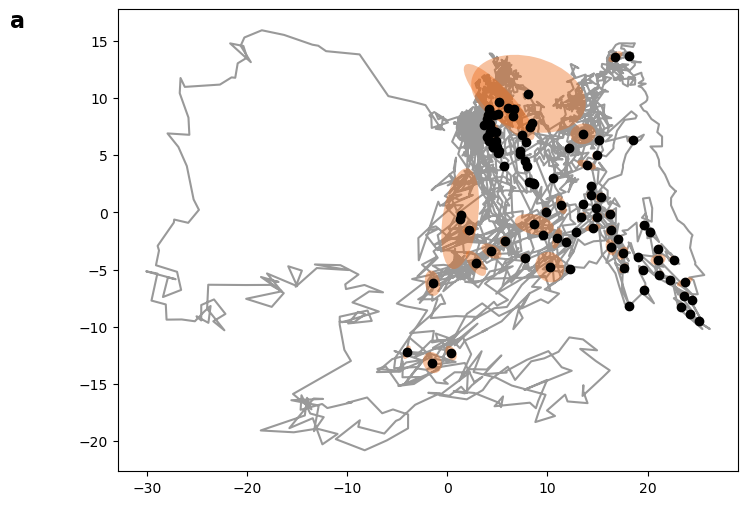

In [19]:
#We need elipses and dots at the same time:
data = smallC_photo
A = bw.A
mu = bw.mu
L = bw.L
n_obs = bw.n_obs

# Create the figure and axis
fig, axs = plt.subplots(figsize=(8, 6))

# Initial plot setup
axs.plot(data[:, 0], data[:, 1], color='gray', alpha=0.8)
scatter = axs.scatter([], [], c='k', zorder=10)
ellipses = []

# Initialize plot elements
def init():
    scatter.set_offsets(np.empty((0, 2)))
    for ellipse in ellipses:
        ellipse.remove()
    ellipses.clear()
    return scatter,

# Update function for animation
def update(frame):
    n = frame
    mask = n_obs >= 0.5
    if mask[n] and n_obs[n] > 0.2:
        el = np.linalg.inv(L[n])
        sig = el.T @ el
        u, s, v = np.linalg.svd(sig)
        width, height = np.sqrt(s[0]) * 3, np.sqrt(s[1]) * 3
        angle = atan2(v[0, 1], v[0, 0]) * 360 / (2 * np.pi)
        ellipse = Ellipse((mu[n, 0], mu[n, 1]), width, height, angle=angle, zorder=8)
        ellipse.set_alpha(0.4)
        ellipse.set_clip_box(axs.bbox)
        ellipse.set_facecolor('#ed6713')
        axs.add_artist(ellipse)
        ellipses.append(ellipse)

    # Update scatter plot
    scatter.set_offsets(mu[mask][:n + 1, :2])
    return scatter,

# Create the animation
ani = FuncAnimation(fig, update, frames=np.arange(len(A)), init_func=init, blit=True, repeat=False)

# Set axis properties
#axs.set_xticks([-2, -1, 0, 1, 2])
#axs.set_yticks([-6, -3, 0, 3, 6])
in1, in2 = -0.15, 1
axs.text(in1, in2, s='a', transform=axs.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# Save or display the animation
ani.save('fishBW_animation2.mp4', writer='ffmpeg', fps=10)  # Uncomment to save
plt.show()

## Now 3D

In [ ]:

smallC_photo_3D = prosvd_data(mediumC_photo.T,3, 20, centering=True)

100%|██████████| 5385/5385 [00:00<00:00, 13742.29it/s]


In [ ]:
## Now in 3D
n_points = 10
theta = np.linspace(0, 2*np.pi, n_points)
phi = np.linspace(0, np.pi, n_points)

# Get the xyz points for plotting
# Cartesian coordinates that correspond to the spherical angles:
X = np.outer(np.cos(theta), np.sin(phi))
Y = np.outer(np.sin(theta), np.sin(phi)).flatten()
Z = np.outer(np.ones_like(theta), np.cos(phi)).flatten()
old_shape = X.shape
X = X.flatten()

data = smallC_photo_3D

A = bw.A
mu = bw.mu
L = bw.L
n_obs = bw.n_obs

axs.plot(data[:,0], data[:,1], data[:,2], color='gray', alpha=0.8)
for n in np.arange(A.shape[0]):
    if n_obs[n] > 1e-4:
        el = np.linalg.inv(L[n]).T
        sig = el @ el.T
        # Find and sort eigenvalues to correspond to the covariance matrix
        eigvals, eigvecs = np.linalg.eigh(sig)
        idx = np.sum(sig,axis=0).argsort()
        eigvals_temp = eigvals[idx]
        idx = eigvals_temp.argsort()
        eigvals = eigvals[idx]
        eigvecs = eigvecs[:,idx]

        # Width, height and depth of ellipsoid
        nstd = 3
        rx, ry, rz = nstd * np.sqrt(eigvals)

        # Rotate ellipsoid for off axis alignment
        a, b, c = np.matmul(eigvecs, np.array([X*rx, Y*ry, Z*rz]))
        a, b, c = a.reshape(old_shape), b.reshape(old_shape), c.reshape(old_shape)

        # Add in offsets for the mean
        a = a + mu[n,0]
        b = b + mu[n,1]
        c = c + mu[n,2]
        
        axs.plot_surface(a, b, c, color='#ff4400', alpha=0.6)

axs.view_init(40, 23)

mask = np.ones(mu.shape[0], dtype=bool)
mask[n_obs < 1e-4] = False
axs.scatter(mu[mask,0], mu[mask,1], mu[mask,2], c='k' , zorder=10)

axs.set_xticks([200, 600, 1000, 1400])
axs.set_yticks([-20, -10, 0, 10])
axs.set_zticks([-1400, -1000, -600, -200])
in1, in2 = 0, 1
axs.text(in1, in2, 100, s='b', transform=axs.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')


ValueError: not enough values to unpack (expected 3, got 2)

In [ ]:
#The covariance matrix has only two eigenvals, 
# This suggests that the covariance matrix is not full rank, and thus has fewer than 3 significant dimensions(?)